# P4 - Architecting an LLM Integration

## Install Python Dependencies and Ollama

This code block installs Ollama, and uses NVIDIA drivers, if they're available on this specific machine. This is going to take a while!

You can select a machine with a GPU by going to `Runtime -> Change Runtime Type`, then select a GPU to hardware accelerate your runtime:
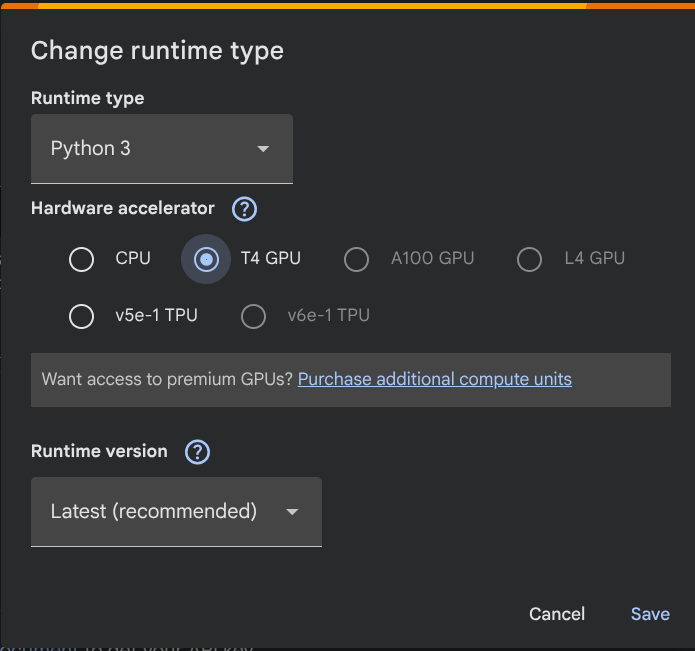

In [ ]:
!curl https://ollama.ai/install.sh | sh
!pip install ollama

!echo 'debconf debconf/frontend select Noninteractive' | sudo debconf-set-selections
!sudo apt-get update && sudo apt-get install -y cuda-drivers

import os
# Set LD_LIBRARY_PATH so the system NVIDIA library
os.environ.update({'LD_LIBRARY_PATH': '/usr/lib64-nvidia'})

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 13281    0 13281    0     0  35935      0 --:--:-- --:--:-- --:--:-- 35991
>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading Linux amd64 bundle
######################################################################## 100.0%
>>> Adding ollama user to render group...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.
Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit

After installation, we need to interact with Ollama programmatically; we can do this via `ollama serve`, which creates a server on `localhost:11434` that our Ollama Python library interacts with to ask prompts to models and get responses.

In [ ]:
import subprocess

process = subprocess.Popen(['ollama', 'serve'])
# Because the process is off on its own, we don't know when it will finish,
# so we'll wait 3s before continuing on to the next cell if
# running sequentially.
!sleep 3

## Select your model and prompt!


Ollama has a whole host of models that are available for you to run. A list is available [here](https://ollama.com/library); make sure to select one that accepts `text` inputs. Here are a couple of models you may want to try out:
- [`qwen3:0.6b`](https://ollama.com/library/qwen3) (qwen3 with 0.6 billion parameters)
- [`gemma3:270m`](https://ollama.com/library/gemma3)
- [`llama3.1:8b`](https://ollama.com/library/llama3.1)

Note that this machine you're running on likely has around 100GB space, and 16GB RAM, and, the larger the model you select, the longer it will take to download (this can take a very long time, up to 15min for a 5GB model). You should try to cover a wide range of possible models across your team; ex. test a large model and a small model.

We've listed a couple models options here for you to choose from; once you select one, and run this cell, this runs `ollama pull <model>` which downloads that specific model. If you'd like to try something different we didn't list out, double-click to edit the cell below, and add your model into the parameter list.

In [ ]:
# @title Select your model, then run this cell
MODEL_NAME = "llama3.1:8b" # @param ["qwen3:0.6b", "deepseek-r1:1.5b", "gemma3:270m", "llama3.1:8b", "mistral:7b", "smollm2:135m"]
!ollama pull {MODEL_NAME}

Now it's time to talk to your model! Feel free to play around here sending your model different messages. You can also specify a context for the model (ex. "You are a developer tool designed to help with...") by adding a message containing your context with `"role": "system"`.

In [ ]:
import os
# Use Ollama library to interact with model:
from ollama import chat, ChatResponse, Client

# Get OLLAMA_HOST, if specified, or default to localhost:11434.
OLLAMA_URL = os.getenv("OLLAMA_HOST", "localhost:11434")

# Initialize the OpenAI client
client = Client(host=OLLAMA_URL)

# Make a request to your Ollama model, running on your Colab server
response = client.chat(
    model=MODEL_NAME,  # model name
    messages=[
        {
            "role": "user",
            "content": "What is the future of artificial intelligence?"
        }
    ]
)

# Print the response
print(response.message.content)

The future of artificial intelligence (AI) is vast and multifaceted, with numerous possibilities and potential applications across various industries. Here are some predictions and trends that may shape the future of AI:

**Short-term (2025-2030)**

1. **Increased adoption**: AI will become more widespread in businesses, homes, and daily life.
2. **Improved natural language processing**: Conversational AI will become more intuitive and user-friendly.
3. **Rise of explainable AI**: Techniques to interpret and understand AI decisions will be developed.
4. **Autonomous systems**: Autonomous vehicles, drones, and robots will become more prevalent.

**Medium-term (2030-2045)**

1. **Advancements in machine learning**: New algorithms and techniques will emerge for complex tasks like image recognition, speech recognition, and natural language generation.
2. **Edge AI**: Computing power will be distributed to the edge of networks, reducing latency and enabling real-time processing.
3. **Human-

### Basic Experimentation (1.5 Points)

One of the most important parts of designing an LLM pipeline, on top of choosing a model, is finding the right **context**. We've provided you with a prompt we've tested for classifying and translating text that works well with the `qwen3:0.6b` model; however, as part of your architectural design and testing document, you can choose to analyze the effectiveness of different contexts.

In [ ]:
import ipywidgets as widgets
from IPython.display import display

# Create a Textarea widget
TRANSLATION_CONTEXT = widgets.Textarea(
    value="""\
You are a language translator. Translate to English if it is not already in English. Follow the examples and do not output extra things.

Example:
INPUT: Bonjour, je m'appelle Bob
OUTPUT: Hello, my name is Bob

INPUT: Können Sie mir bitte helfen?
OUTPUT: Can you please help me?

INPUT: ¡Hola! ¿Cómo estás?
OUTPUT: Hello! How are you?

INPUT: Hello! How are you?
OUTPUT: Hello! How are you?
""",
    description='TRANSLATION_CONTEXT:',
    layout=widgets.Layout(width='60%', height='200px'),
    style={"description_width": "190px"}
)

CLASSIFICATION_CONTEXT = widgets.Textarea(
    value="""\
You are a language classifier. Detect the language of the input text and reply only with the English name of that language. If you don't know the language, reply with "Unknown".
If it is a combination of multiple languages, reply with the most likely language with the most percentage in the text, ALWAYS output only one language instead of multiple ones.
For simplified Chinese, tradional Chinese, Cantonese, or other Chinese dialect, reply the word "Chinese".
For, English, don't reply with English-US or English_GB, but rather just "English".
Example:
INPUT: Bonjour, je m'appelle Bob
OUTPUT: French

INPUT: Können Sie mir bitte helfen?
OUTPUT: German

INPUT: ¡Hola! ¿Cómo estás?
OUTPUT: Spanish

INPUT: Hello! How are you?
OUTPUT: English

INPUT: 你好Andrew！你今天过的怎么样？
OUTPUT: Chinese
""",
    description='CLASSIFICATION_CONTEXT:',
    layout=widgets.Layout(width='60%', height='200px'),
    style={"description_width": "190px"}
)

# Display the widget
display(TRANSLATION_CONTEXT)
display(CLASSIFICATION_CONTEXT)

# You can access the value of the textarea
# For example, after you've filled it in:
# print(TRANSLATION_CONTEXT.value)

Textarea(value="You are a language translator. Translate to English if it is not already in English. Follow th…

Textarea(value='You are a language classifier. Detect the language of the input text and reply only with the E…

*Before* we jump into building, your manager asks you to make sure that LLMs are suitable for the machine translation task. Implement the `get_translation` function provided below to translate non-English posts into English. Use the Ollama library to query the `MODEL_NAME` model you specified earlier. Feel free to add any helper functions and cells.

In [ ]:
# TODO: Implement Basic LLM integration
def get_translation(post: str) -> str:
    context = TRANSLATION_CONTEXT.value
    # ---------------- YOUR CODE HERE ---------------- #
    response = client.chat(
        model=MODEL_NAME,
        messages=[
            {"role": "system", "content": context},
            {"role": "user", "content": f"Translate the following text to English. Only give translation and nothing else.\n{post}"}
        ]
    )
    return response.message.content

In [ ]:
get_translation("Hier ist dein erstes Beispiel.")

'Here is your first example.'

In [ ]:
get_translation("你好，很高兴认识你！")

"Hello, it's nice to meet you!"

In [ ]:
get_translation("Hi, how are you?")

'Hello, how are you?'

Similarly, you want to make sure that the LLM is capable of classifying English and non-English text. Although this is sometimes considered a solved problem within Natural Language Processing, recent research suggests that not all ML models accurately classify some English dialects and you want to avoid an embarassing screw up with NodeBB.

Optional reading [here](https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=10313241).

In [ ]:
# TODO: Implement Basic LLM integration
def get_language(post: str) -> str:
    context = CLASSIFICATION_CONTEXT.value
    # ---------------- YOUR CODE HERE ---------------- #
    response = client.chat(
        model=MODEL_NAME,
        messages=[
            {"role": "system", "content": context},
            {"role": "user", "content": f"Detect the language of the following text:\n{post}"}
        ]
    )
    return response.message.content

In [ ]:
get_language("Hier ist dein erstes Beispiel.")

'German'

Now that you have set up the basic functionality of the LLM, we would like to evaluate its performance.

### Evaluation

#### Evaluation Dataset (1.5 Points)

First, create two evaluation datasets containing example post/answer pairs, one for the translation task and one for the language classification task. Make sure each dataset has **at least 10 post-answer pairs.** Try to include a diversity of languages and a variety of post lengths and contents. You may find Google Translate, DeepL, ChatGPT, or a similar tool helpful in creating your examples.

Each dataset should be a list of dictionaries containing posts and answers. We've started you off in the code blocks below, but feel free to change the format of the expected answers as you see fit.

In [ ]:
translation_eval_set = [
    {
        "post": "Hier ist dein erstes Beispiel.",
        "expected_answer": "Here is your first example."
    },
    {
        "post": "Bonjour, comment ça va?",
        "expected_answer": "Hello, how are you?"
    },
    {
        "post": "¡Hola! ¿Cómo estás?",
        "expected_answer": "Hello! How are you?"
    },
    {
        "post": "你好，很高兴认识你。",
        "expected_answer": "Hello, nice to meet you."
    },
    {
        "post": "Olá, como você está?",
        "expected_answer": "Hello, how are you?"
    },
    {
        "post": "Привет, как дела?",
        "expected_answer": "Hello, how are you?"
    },
    {
        "post": "こんにちは、お元気ですか？",
        "expected_answer": "Hello, how are you?"
    },
    {
        "post": "안녕하세요, 잘 지내세요?",
        "expected_answer": "Hello, how are you?"
    },
    {
        "post": "Ciao, come stai?",
        "expected_answer": "Hello, how are you?"
    },
    {
        "post": "Hej, hur mår du?",
        "expected_answer": "Hello, how are you?"
    },
    {
        "post": "Labas, kaip tau sekasi?",
        "expected_answer": "Hello, how are you?"
    },
    {
        "post": "Hei, miten menee?",
        "expected_answer": "Hello, how are you?"
    },
    {
        "post": "שלום מה נשמע",
        "expected_answer": "Hello what's up"
    },
    {
        "post": "مرحباً، كيف حالك؟",
        "expected_answer": "Hello, how are you?"
    },
    {
        "post": "¿Qué hora es?",
        "expected_answer": "What time is it?"
    },
    {
        "post": "Il pleut aujourd'hui.",
        "expected_answer": "It's raining today."
    },
    {
        "post": "Das Wetter ist schön.",
        "expected_answer": "The weather is nice."
    },
    {
        "post": "今天天气很好。",
        "expected_answer": "The weather is good today."
    },
    {
        "post": "Que horas são?",
        "expected_answer": "What time is it?"
    },
    {
        "post": "Какая сегодня погода?",
        "expected_answer": "What is the weather today?"
    },
    {
        "post": "What is the weather today?",
        "expected_answer": "What is the weather today?"
    }
]

In [ ]:
language_detection_eval_set = [
    {
        "post": "Hier ist dein erstes Beispiel.",
        "expected_answer": "German"
    },
    {
        "post": "Bonjour, comment ça va?",
        "expected_answer": "French"
    },
    {
        "post": "¡Hola! ¿Cómo estás?",
        "expected_answer": "Spanish"
    },
    {
        "post": "你好，很高兴认识你。",
        "expected_answer": "Chinese"
    },
    {
        "post": "Olá, como você está?",
        "expected_answer": "Portuguese"
    },
    {
        "post": "Привет, как дела?",
        "expected_answer": "Russian"
    },
    {
        "post": "こんにちは、お元気ですか？",
        "expected_answer": "Japanese"
    },
    {
        "post": "안녕하세요, 잘 지내세요?",
        "expected_answer": "Korean"
    },
    {
        "post": "Ciao, come stai?",
        "expected_answer": "Italian"
    },
    {
        "post": "Hej, hur mår du?",
        "expected_answer": "Swedish"
    },
    {
        "post": "Labas, kaip tau sekasi?",
        "expected_answer": "Lithuanian"
    },
    {
        "post": "Hei, miten menee?",
        "expected_answer": "Finnish"
    },
    {
        "post": "שלום מה נשמע",
        "expected_answer": "Hebrew"
    },
    {
        "post": "مرحباً، كيف حالك؟",
        "expected_answer": "Arabic"
    },
    {
        "post": "¿Qué hora es?",
        "expected_answer": "Spanish"
    },
    {
        "post": "Il pleut aujourd'hui.",
        "expected_answer": "French"
    },
    {
        "post": "Das Wetter ist schön.",
        "expected_answer": "German"
    },
    {
        "post": "今天天气很好。",
        "expected_answer": "Chinese"
    },
    {
        "post": "Que horas são?",
        "expected_answer": "Portuguese"
    },
    {
        "post": "Какая сегодня погода?",
        "expected_answer": "Russian"
    },
    {
        "post": "This is an English post.",
        "expected_answer": "English"
    }
]

#### Evaluation Metrics (2 Points)
Choose a metric to measure performance of the LLM on each evaluation dataset you have created. If you would like, you can define any helper functions below in this section. You'll find the [sbert](https://www.sbert.net/docs/quickstart.html#comparing-sentence-similarities) library to be helpful.

Note that you will probably want a different evaluation metric for your language classification and translation tasks because classification has one correct answer while translation may have a spectrum of correct answers.

In [ ]:
%pip install sentence_transformers --quiet

from sentence_transformers import SentenceTransformer, util
model = SentenceTransformer('all-MiniLM-L6-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
from sentence_transformers import SentenceTransformer
import torch.nn.functional as F # Import PyTorch's functional module

model = SentenceTransformer('all-MiniLM-L6-v2')

def eval_single_response_translation(expected_answer: str, llm_response: str) -> float:
  '''TODO: Compares an LLM response to the expected answer from the evaluation dataset using one of the text comparison metrics.'''
  # ----------------- YOUR CODE HERE ------------------ #
  embeddings1 = model.encode(expected_answer, convert_to_tensor=True)
  embeddings2 = model.encode(llm_response, convert_to_tensor=True)
  # Use PyTorch's cosine_similarity
  cosine_scores = F.cosine_similarity(embeddings1.unsqueeze(0), embeddings2.unsqueeze(0))
  return cosine_scores.item()

In [ ]:
def eval_single_response_classification(expected_answer: str, llm_response: str) -> float:
  '''TODO: Compares an LLM response to the expected answer from the evaluation dataset using one of the text comparison metrics.'''
  # ----------------- YOUR CODE HERE ------------------ #
  return float(expected_answer.strip().lower() == llm_response.strip().lower())

The function below can take a while; if you'd like to see a progress bar of how it's progressing through the dataset, you can use [tqdm](https://github.com/tqdm/tqdm)! (this is optional)

In [ ]:
from typing import Callable
from tqdm.notebook import tqdm

def evaluate(query_fn: Callable[[str], str], eval_fn: Callable[[str, str], float], dataset) -> float:
  '''
  TODO: Computes an aggregate score of the chosen evaluation metric across the given dataset. Calls the query_fn function to generate
  LLM outputs for each of the posts in the evaluation dataset, and calls eval_single_response to calculate the metric.
  '''
  # ----------------- YOUR CODE HERE ------------------ #
  total_score = 0
  for item in tqdm(dataset):
      post = item["post"]
      expected_answer = item["expected_answer"]
      llm_response = query_fn(post)
      total_score += eval_fn(expected_answer, llm_response)
  return total_score / len(dataset)

Run your basic LLM implementation on the evaluation dataset and report the performance.

In [ ]:
translation_eval_score = evaluate(get_translation, eval_single_response_translation, translation_eval_set)

print(f"Translation Evaluation Score: {translation_eval_score}")

  0%|          | 0/21 [00:00<?, ?it/s]

Translation Evaluation Score: 0.9653493336268834


In [ ]:
classification_eval_score = evaluate(get_language, eval_single_response_classification, language_detection_eval_set)

print(f"Classification Evaluation Score: {classification_eval_score}")

  0%|          | 0/21 [00:00<?, ?it/s]

Classification Evaluation Score: 1.0


### Querying for Success

#### Evaluation Set (1.5 Points)
Now that you're confident in the LLM's translation and language detection abilities, you want to begin work on your actual queries. But first, create an evaluation set called `translation_eval_set` that includes at least 15 English posts, at least 15 non-English posts, and at least 5 unintelligible or malformed posts. You may reuse your posts from earlier tasks. Your output format should be a tuple with a boolean indicating whether the post is in English and a string with the translation of a non-English post into English. Use your best judgement about what string to expect when the post is already in English.

**It is very important that you do not make ANY assumptions about the contents of the submitted post.**

In [ ]:
complete_eval_set = [
    {
        "post": "Hier ist dein erstes Beispiel.",
        "expected_answer": (False, "This is your first example.")
    },
    {
        "post": "Bonjour, comment ça va?",
        "expected_answer": (False, "Hello, how are you?")
    },
    {
        "post": "¡Hola! ¿Cómo estás?",
        "expected_answer": (False, "Hello! How are you?")
    },
    {
        "post": "你好，很高兴认识你。",
        "expected_answer": (False, "Hello, nice to meet you.")
    },
    {
        "post": "Olá, como você está?",
        "expected_answer": (False, "Hello, how are you?")
    },
    {
        "post": "Привет, как дела?",
        "expected_answer": (False, "Hello, how are you?")
    },
    {
        "post": "こんにちは、お元気ですか？",
        "expected_answer": (False, "Hello, how are you?")
    },
    {
        "post": "안녕하세요, 잘 지내세요?",
        "expected_answer": (False, "Hello, how are you?")
    },
    {
        "post": "Ciao, come stai?",
        "expected_answer": (False, "Hello, how are you?")
    },
    {
        "post": "Hej, hur mår du?",
        "expected_answer": (False, "Hello, how are you?")
    },
    {
        "post": "Labas, kaip tau sekasi?",
        "expected_answer": (False, "Hello, how are you?")
    },
    {
        "post": "Hei, miten menee?",
        "expected_answer": (False, "Hello, how are you?")
    },
    {
        "post": "שלום מה נשמע",
        "expected_answer": (False, "Hello what's up")
    },
    {
        "post": "مرحباً، كيف حالك؟",
        "expected_answer": (False, "Hello, how are you?")
    },
    {
        "post": "¿Qué hora es?",
        "expected_answer": (False, "What time is it?")
    },
    {
        "post": "Il pleut aujourd'hui.",
        "expected_answer": (False, "It's raining today.")
    },
    {
        "post": "Das Wetter ist schön.",
        "expected_answer": (False, "The weather is nice.")
    },
    {
        "post": "今天天气很好。",
        "expected_answer": (False, "The weather is good today.")
    },
    {
        "post": "Que horas são?",
        "expected_answer": (False, "What time is it?")
    },
    {
        "post": "Какая сегодня погода?",
        "expected_answer": (False, "What is the weather today?")
    },
    {
        "post": "This is an English post.",
        "expected_answer": (True, "This is an English post.")
    },
    {
        "post": "Hello, how are you doing today?",
        "expected_answer": (True, "Hello, how are you doing today?")
    },
    {
        "post": "The quick brown fox jumps over the lazy dog.",
        "expected_answer": (True, "The quick brown fox jumps over the lazy dog.")
    },
    {
        "post": "Artificial intelligence is a fascinating field.",
        "expected_answer": (True, "Artificial intelligence is a fascinating field.")
    },
    {
        "post": "Learning to program can be challenging but rewarding.",
        "expected_answer": (True, "Learning to program can be challenging but rewarding.")
    },
    {
        "post": "I love spending time outdoors.",
        "expected_answer": (True, "I love spending time outdoors.")
    },
    {
        "post": "What are your plans for the weekend?",
        "expected_answer": (True, "What are your plans for the weekend?")
    },
    {
        "post": "Reading a good book is a great way to relax.",
        "expected_answer": (True, "Reading a good book is a great way to relax.")
    },
    {
        "post": "Tell me about your favorite hobby.",
        "expected_answer": (True, "Tell me about your favorite hobby.")
    },
    {
        "post": "The weather forecast for tomorrow is sunny.",
        "expected_answer": (True, "The weather forecast for tomorrow is sunny.")
    },
    {
        "post": "I'm looking forward to the holidays.",
        "expected_answer": (True, "I'm looking forward to the holidays.")
    },
    {
        "post": "Do you enjoy cooking?",
        "expected_answer": (True, "Do you enjoy cooking?")
    },
    {
        "post": "Traveling to new places is exciting.",
        "expected_answer": (True, "Traveling to new places is exciting.")
    },
    {
        "post": "What's your favorite type of music?",
        "expected_answer": (True, "What's your favorite type of music?")
    },
    {
        "post": "Let's grab some coffee sometime.",
        "expected_answer": (True, "Let's grab some coffee sometime.")
    },
    {
        "post": "It's important to stay hydrated.",
        "expected_answer": (True, "It's important to stay hydrated.")
    },
     {
        "post": "你好。吃饭了吗？",
        "expected_answer": (False, "Hello. Have you eaten?")
    },
    {
        "post": "今天天气怎么样？",
        "expected_answer": (False, "How is the weather today?")
    },
    {
        "post": "我喜欢学习编程。",
        "expected_answer": (False, "I like to learn programming.")
    },
    {
        "post": "音乐是我的爱好。",
        "expected_answer": (False, "Music is my hobby.")
    },
    {
        "post": "周末你有什么计划？",
        "expected_answer": (False, "What are your plans for the weekend?")
    },
    {
        "post": "阅读让我放松。",
        "expected_answer": (False, "Reading relaxes me.")
    },
    {
        "post": "旅行是我的梦想。",
        "expected_answer": (False, "Traveling is my dream.")
    },
    {
        "post": "你喜欢什么类型的电影？",
        "expected_answer": (False, "What type of movies do you like?")
    },
    {
        "post": "我们什么时候见面？",
        "expected_answer": (False, "When shall we meet?")
    },
    {
        "post": "这道菜很好吃。",
        "expected_answer": (False, "This dish is delicious.")
    },
    {
        "post": "我正在学习新的语言。",
        "expected_answer": (False, "I am learning a new language.")
    },
    {
        "post": "请问洗手间在哪里？",
        "expected_answer": (False, "Excuse me, where is the restroom?")
    },
    {
        "post": "祝你有个愉快的一天！",
        "expected_answer": (False, "Have a nice day!")
    },
    {
        "post": "谢谢你的帮助。",
        "expected_answer": (False, "Thank you for your help.")
    },
    {
        "post": "再见！",
        "expected_answer": (False, "Goodbye!")
    },
    {
        "post": "asdfghjkl",
        "expected_answer": (True, "asdfghjkl")
    },
    {
        "post": "12345",
        "expected_answer": (True, "12345")
    },
    {
        "post": "!@#$%^",
        "expected_answer": (True, "!@#$%^")
    },
    {
        "post": "",
        "expected_answer": (True, "")
    },
    {
        "post": " ",
        "expected_answer": (True, " ")
    }
]

#### Implementation (3.5 Points)

Implement the `query_llm` function that takes in a NodeBB post and outputs a response in your expected format. You may wish to experiment with a variety of querying strategies, including those discussed in lecture.

In [ ]:
def query_llm(post: str) -> tuple[bool, str]:
  # ----------------- YOUR CODE HERE ------------------ #
  language = get_language(post)
  is_english = language.strip().lower() == "english"
  if is_english:
    return (True, post)
  else:
    translation = get_translation(post)
    return (False, translation)

In [ ]:
query_llm("Hier ist dein erstes Beispiel.")

(False, 'Here is your first example.')

In [ ]:
query_llm("Hello how are you?")

(True, 'Hello how are you?')

In [ ]:
query_llm("Hi，你今天开心吗？")

(False, 'Hello, are you happy today?')

You may also need a new evaluation function for this format. Feel free to call your existing evaluation functions or create a completely new one. This will be scored with the other evaluation functions above.

In [ ]:
def eval_single_response_complete(expected_answer: tuple[bool, str], llm_response: tuple[bool, str]) -> float:
  '''TODO: Compares an LLM response to the expected answer from the evaluation dataset using one of the text comparison metrics.'''
  # ----------------- YOUR CODE HERE ------------------ #
  expected_is_english, expected_text = expected_answer
  llm_is_english, llm_text = llm_response

  # Check if the language classification is correct
  if expected_is_english != llm_is_english:
      return 0.0

  # If it's English, check for exact text match
  if expected_is_english:
      return float(expected_text.strip() == llm_text.strip())
  # If it's not English, evaluate the translation using sentence similarity
  else:
      return eval_single_response_translation(expected_text, llm_text)

In [ ]:
eval_score = evaluate(query_llm, eval_single_response_complete, complete_eval_set)

print(f"Evaluation Score: {eval_score}")

  0%|          | 0/56 [00:00<?, ?it/s]

Evaluation Score: 0.8742104225925037


##Mocking up a Storm
Because NodeBB now relies very heavily on an external library and framework (Ollama), we have introduced new risks into our platform. Even if our integration works perfectly today, Ollama could decide to change the structure of their library tomorrow. While we can pin a specific version, it's important to stay up-to-date with incoming changes Ollama makes, and part of that is staying on top of changes that may jeopardize our platform. For this task, you will modify your `query_llm` function from above to fail gracefully in the event of unexpected model responses or states and test your new function with both normal and unexpected model responses.

### Handle Errors (3 points)

Copy your `query_llm` function from above. Modify it so that you check whether your model's output is in your expected format. If it is not in the correct format, your new function should allow NodeBB to handle the error gracefully (that is, NodeBB should not break and should continue to provide an okay user experience). In the provided space below, please briefly describe how your function responds to poorly formatted model outputs and how you plan to use these responses in your NodeBB integration.

Note that we do not expect you to verify that the language classification or translation is correct, only that it could be correct for some input. As with before, we expect your querying function to be robust in the face of any textual input.

In [ ]:
def query_llm_robust(post: str) -> tuple[bool, str]:
  '''
  TODO: Implement this
  '''
  # ----------------- YOUR CODE HERE ------------------ #
  try:
    language = get_language(post)
    # Handle unexpected language detection responses
    if language.strip().lower() not in ["english", "german", "french", "spanish", "chinese", "portuguese", "russian", "japanese", "korean", "italian", "swedish", "lithuanian", "finnish", "hebrew", "arabic"]:
         return (True, post) # Graceful fallback for unexpected language

    is_english = language.strip().lower() == "english"
    if is_english:
      return (True, post)
    else:
      translation = get_translation(post)
      # Basic check for empty or unintelligible translation
      if not translation.strip():
          return (True, post) # Graceful fallback for empty/unintelligible translation
      return (False, translation)
  except Exception as e:
    # Catch any other exceptions during the process and return original post
    print(f"Error processing post: {e}")
    return (True, post) # Assume English and return original post as graceful fallback

BRIEFLY EXPLAIN YOUR TEAM'S STRATEGY FOR HANDLING ERRORS HERE



---


It adds checks for unexpected language classification results and empty translations, returning (True, original_post) as a graceful fallback in these specific cases, so the output will just be the original post because there are no way to translate them.

It also catches any other exceptions during the process and returns (True, original_post) as a general fallback.



---



### Test Robustness (2 points)

Mocking is a common strategy in software engineering for unit testing. It allows us to simulate the behavior of an object, such as a microservice or API call, which can be helpful when the object is not yet complete, slow, nondeterministic or has rare states that we want to test (such as a service being down). In this case, we will mock the behavior of the LLM so that it will simulate the LLM returning unexpected or malformed results.

You should refer to [this](https://docs.python.org/3/library/unittest.mock.html) Python documentation as you go through this task.

You may (optionally) read more about mocking in Python [here](https://www.fugue.co/blog/2016-02-11-python-mocking-101).

For this task, you should write at least four tests that deal with unexpected model behavior.

In [ ]:
%pip install --quiet pytest ipytest pytest-mock mock

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 86.0 MB/s eta 0:00:00


In [ ]:
from mock import patch

@patch.object(client, 'chat')
def test_unexpected_language(mocker):
  # Test case 1: Mocking an unexpected language detection response
  mocker.return_value.message.content = "I don't understand your request"
  is_english, translated_text = query_llm_robust("Hier ist dein erstes Beispiel.")
  # Expecting it to fallback to assuming English and returning the original post
  assert is_english is True
  assert translated_text == "Hier ist dein erstes Beispiel."

@patch.object(client, 'chat')
def test_empty_translation(mocker):
  # Test case 2: Mocking an empty translation response after language detection
  original_post = "Hier ist dein erstes Beispiel." # Define original_post
  def side_effect(model, messages):
      if "Detect the language" in messages[1]['content']:
          return type('obj', (object,), {'message': type('obj', (object,), {'content': 'German'})})()
      elif "Translate the following text" in messages[1]['content']:
          return type('obj', (object,), {'message': type('obj', (object,), {'content': ''})})()
      return None

  mocker.side_effect = side_effect
  is_english, translated_text = query_llm_robust(original_post) # Pass original_post
  # Expecting it to return the original post as graceful fallback for empty translation
  assert is_english is True # Changed expectation
  assert translated_text == original_post # Changed expectation


@patch.object(client, 'chat')
def test_ollama_exception(mocker):
    # Test case 3: Mocking an exception during the Ollama call
    mocker.side_effect = Exception("Ollama server is down")
    is_english, translated_text = query_llm_robust("Hier ist dein erstes Beispiel.")
    # Expecting it to fallback to assuming English and returning the original post
    assert is_english is True
    assert translated_text == "Hier ist dein erstes Beispiel."

@patch.object(client, 'chat')
def test_unintelligible_post(mocker):
    # Test case 4: Test with an unintelligible post
    original_post = "asdfghjkl" # Define original_post
    def side_effect(model, messages):
        if "Detect the language" in messages[1]['content']:
            return type('obj', (object,), {'message': type('obj', (object,), {'content': 'Unknown'})})()
        elif "Translate the following text" in messages[1]['content']:
            return type('obj', (object,), {'message': type('obj', (object,), {'content': ''})})()
        return None

    mocker.side_effect = side_effect
    is_english, translated_text = query_llm_robust(original_post) # Pass original_post
    # Expecting it to fallback to assuming English and returning the original post
    assert is_english is True
    assert translated_text == original_post

Run the tests.

In [ ]:
import ipytest
ipytest.run('-vv')

======================================= test session starts ========================================
platform linux -- Python 3.12.12, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content
plugins: mock-3.15.1, anyio-4.11.0, langsmith-0.4.40, typeguard-4.4.4
collecting ... collected 4 items

t_aa712eb806554138a27b471b5f959005.py::test_unexpected_language <- ../tmp/ipython-input-1681594188.py PASSED [ 25%]
t_aa712eb806554138a27b471b5f959005.py::test_empty_translation <- ../tmp/ipython-input-1681594188.py PASSED [ 50%]
t_aa712eb806554138a27b471b5f959005.py::test_ollama_exception <- ../tmp/ipython-input-1681594188.py PASSED [ 75%]
t_aa712eb806554138a27b471b5f959005.py::test_unintelligible_post <- ../tmp/ipython-input-1681594188.py PASSED [100%]

========================================= warnings summary =========================================
../usr/local/lib/python3.12/dist-packages/_pytest/config/__init__.py:1290
  /usr/local/lib/python3.12/dist-pack

<ExitCode.OK: 0>

Finally, we want to make sure that our modified function still works for normal inputs, so let's test it to find out!

In [ ]:
query_llm_robust("Hier ist dein erstes Beispiel.")

(False, 'Here is your first example.')

In [ ]:
eval_score = evaluate(query_llm_robust, eval_single_response_complete, complete_eval_set)

print(f"Evaluation Score: {eval_score}")

  0%|          | 0/56 [00:00<?, ?it/s]

Evaluation Score: 0.9704433503959861


Here is a list of other models we've experimented, but their performance are not as good:

Qwen:
https://colab.research.google.com/drive/1mK3XR9u7lOrEVO4Bm_NDEWdRQ6cDrx4F?usp=drive_link

Mistral:
https://colab.research.google.com/drive/14eiSPQEMwocJJ_Z_PpUzEBnY25VuZjZM?usp=drive_link